In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="darkgrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

chunks = []
for chunk in pd.read_csv(
    "/content/drive/MyDrive/ciciot2023_consolidado.csv",
    chunksize=500000,
    low_memory=False
):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (8450000, 47)
Columnas: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


## ESTADISTICAS DESCRIPTIVAS

In [3]:
display(df.describe())

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,...,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06,8.450000e+06
mean,5.735213e+00,7.654847e+04,9.065205e+00,6.633625e+01,9.007475e+03,9.007475e+03,1.085713e-05,8.647893e-02,2.073460e-01,9.038166e-02,...,1.246663e+02,3.333754e+01,1.246355e+02,8.319126e+07,9.498884e+00,1.312085e+01,4.711421e+01,3.076603e+04,9.640442e-02,1.415226e+02
std,2.789620e+02,4.612578e+05,8.945351e+00,1.395288e+01,9.890255e+04,9.890255e+04,1.251344e-02,2.810700e-01,4.054056e-01,2.867278e-01,...,2.410742e+02,1.604892e+02,2.413646e+02,1.702139e+07,8.179336e-01,8.629994e+00,2.269917e+02,3.227165e+05,2.329907e-01,2.103580e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.092747e+00,2.092747e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.577011e+01,1.577011e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.050578e-01,2.856500e+02,1.440000e+01,6.400000e+01,1.180912e+02,1.180912e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.404623e+01,3.719096e-01,5.406000e+01,8.334391e+07,9.500000e+00,1.039662e+01,5.059213e-01,1.344216e+00,8.000000e-02,1.415500e+02
max,1.866983e+05,9.907148e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,2.971522e+01,1.000000e+00,1.000000e+00,1.000000e+00,...,1.102946e+04,1.093214e+04,9.998400e+03,1.676394e+08,1.500000e+01,1.434332e+02,1.546038e+04,1.435427e+08,1.000000e+00,2.446000e+02


## VALORES NULOS POR COLUMNA

In [4]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': nulos_pct
}).sort_values('porcentaje', ascending=False)

print(resumen_nulos[resumen_nulos['nulos'] > 0])
print(f"\nTotal de columnas con nulos: {(nulos > 0).sum()}")

Empty DataFrame
Columns: [nulos, porcentaje]
Index: []

Total de columnas con nulos: 0


## DUPLICADOS

In [5]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados:,}")
print(f"Porcentaje: {round(duplicados / len(df) * 100, 4)}%")

Filas duplicadas: 2
Porcentaje: 0.0%


## Distribucion de clases

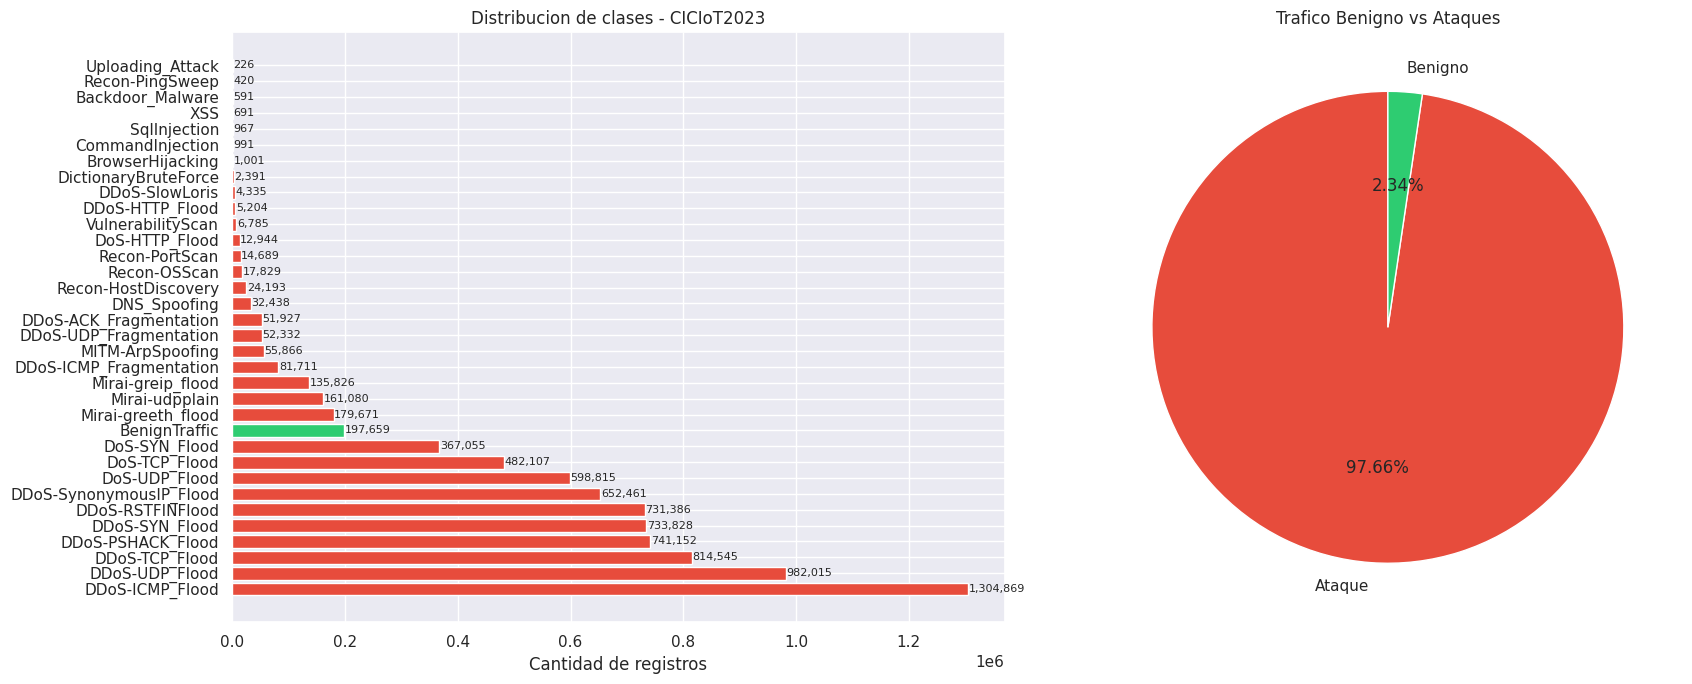


Total clases: 34
label
DDoS-ICMP_Flood            1304869
DDoS-UDP_Flood              982015
DDoS-TCP_Flood              814545
DDoS-PSHACK_Flood           741152
DDoS-SYN_Flood              733828
DDoS-RSTFINFlood            731386
DDoS-SynonymousIP_Flood     652461
DoS-UDP_Flood               598815
DoS-TCP_Flood               482107
DoS-SYN_Flood               367055
BenignTraffic               197659
Mirai-greeth_flood          179671
Mirai-udpplain              161080
Mirai-greip_flood           135826
DDoS-ICMP_Fragmentation      81711
MITM-ArpSpoofing             55866
DDoS-UDP_Fragmentation       52332
DDoS-ACK_Fragmentation       51927
DNS_Spoofing                 32438
Recon-HostDiscovery          24193
Recon-OSScan                 17829
Recon-PortScan               14689
DoS-HTTP_Flood               12944
VulnerabilityScan             6785
DDoS-HTTP_Flood               5204
DDoS-SlowLoris                4335
DictionaryBruteForce          2391
BrowserHijacking              1

In [7]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# barras horizontal
colors = ['#e74c3c' if x != 'BenignTraffic' else '#2ecc71' for x in label_counts.index]
axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel("Cantidad de registros")
axes[0].set_title("Distribucion de clases - CICIoT2023")
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=8)

# ataque vs benigno
ataque_vs_benigno = df['label'].apply(lambda x: 'Benigno' if x == 'BenignTraffic' else 'Ataque').value_counts()
axes[1].pie(
    ataque_vs_benigno.values,
    labels=ataque_vs_benigno.index,
    autopct='%1.2f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90
)
axes[1].set_title("Trafico Benigno vs Ataques")

plt.tight_layout()
plt.savefig("distribucion_clases.png", bbox_inches='tight')
plt.show()
print(f"\nTotal clases: {label_counts.nunique()}")
print(label_counts)

## Distribucion por categoria de ataque

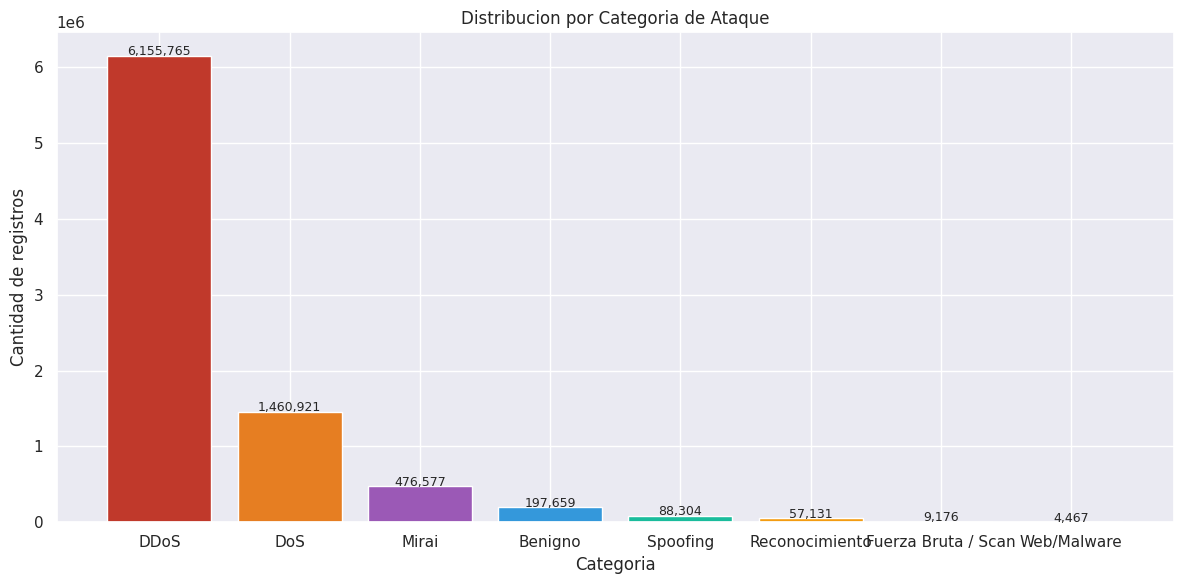

categoria
DDoS                   6155765
DoS                    1460921
Mirai                   476577
Benigno                 197659
Spoofing                 88304
Reconocimiento           57131
Fuerza Bruta / Scan       9176
Web/Malware               4467
Name: count, dtype: int64


In [9]:
def categorizar(label):
    if label == 'BenignTraffic':
        return 'Benigno'
    elif 'DDoS' in label:
        return 'DDoS'
    elif 'DoS' in label:
        return 'DoS'
    elif 'Mirai' in label:
        return 'Mirai'
    elif 'Recon' in label:
        return 'Reconocimiento'
    elif label in ['MITM-ArpSpoofing', 'DNS_Spoofing']:
        return 'Spoofing'
    elif label in ['BrowserHijacking', 'CommandInjection', 'SqlInjection', 'XSS', 'Backdoor_Malware', 'Uploading_Attack']:
        return 'Web/Malware'
    elif label in ['DictionaryBruteForce', 'VulnerabilityScan']:
        return 'Fuerza Bruta / Scan'
    else:
        return 'Otros'

df['categoria'] = df['label'].apply(categorizar)
cat_counts = df['categoria'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#c0392b','#e67e22','#9b59b6','#3498db','#1abc9c','#f39c12','#e74c3c','#2ecc71']
bars = ax.bar(cat_counts.index, cat_counts.values, color=colores[:len(cat_counts)])
ax.set_title("Distribucion por Categoria de Ataque")
ax.set_xlabel("Categoria")
ax.set_ylabel("Cantidad de registros")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{bar.get_height():,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("categorias_ataque.png", bbox_inches='tight')
plt.show()

print(cat_counts)

## Outliers con IQR

In [10]:
features_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_resumen = []
for col in features_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    outlier_resumen.append({
        'feature': col,
        'outliers': outliers,
        'porcentaje': round(outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_resumen).sort_values('porcentaje', ascending=False)
print("TOP 15 FEATURES CON MAS OUTLIERS")
print("=" * 60)
print(outlier_df.head(15).to_string(index=False))

TOP 15 FEATURES CON MAS OUTLIERS
        feature  outliers  porcentaje
            Max   2701977       31.98
            AVG   2598046       30.75
       Tot size   2597395       30.74
        Tot sum   2585394       30.60
       Magnitue   2585183       30.59
            Min   2424892       28.70
       Duration   2241337       26.52
  Header_Length   2076885       24.58
      syn_count   2022512       23.94
     Covariance   1908762       22.59
      rst_count   1897028       22.45
          Srate   1859983       22.01
           Rate   1859983       22.01
            UDP   1791343       21.20
syn_flag_number   1752074       20.73


## Heatmap de correlacion

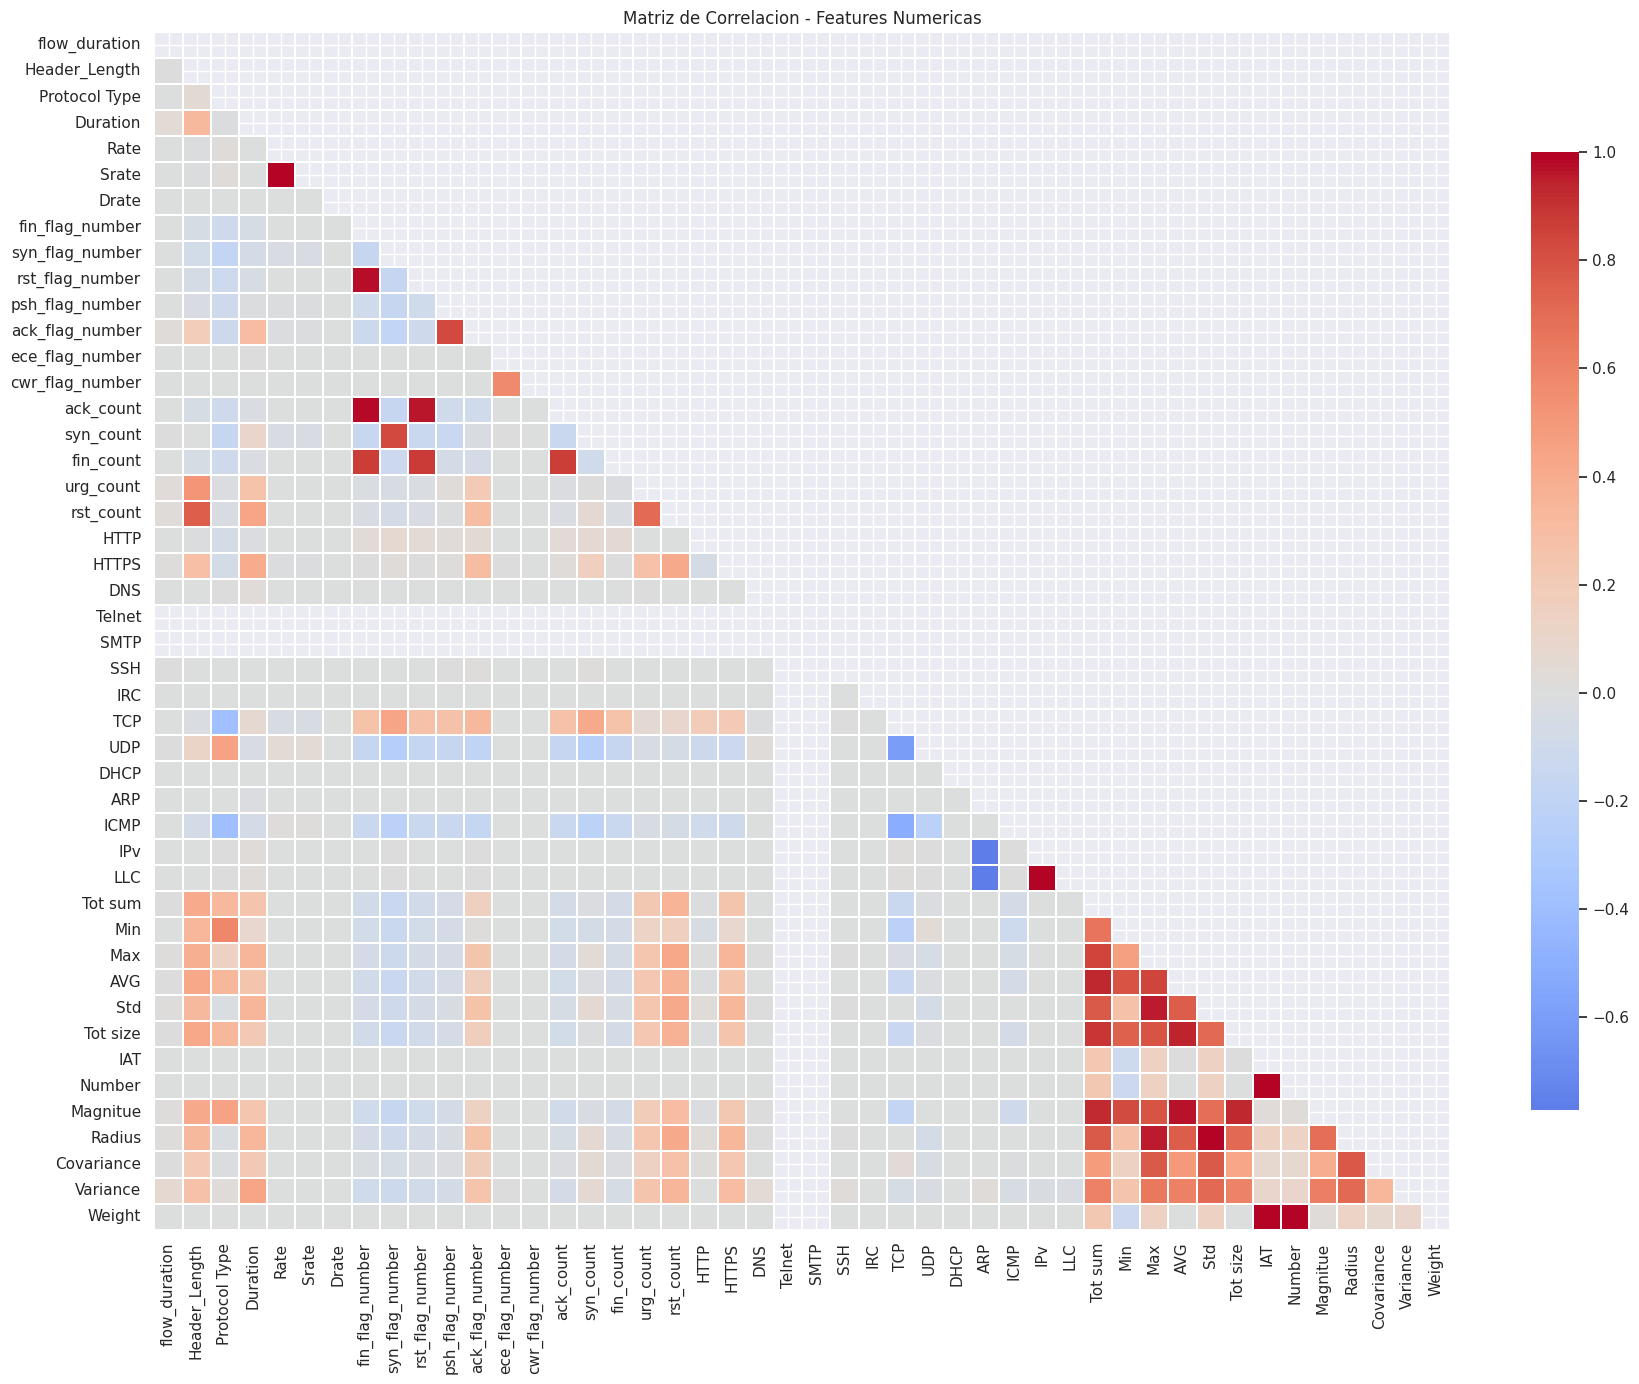

In [11]:
corr_matrix = df[features_numericas].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlacion - Features Numericas")
plt.tight_layout()
plt.savefig("correlacion.png", bbox_inches='tight')
plt.show()

## Distribucion de las top 6 features

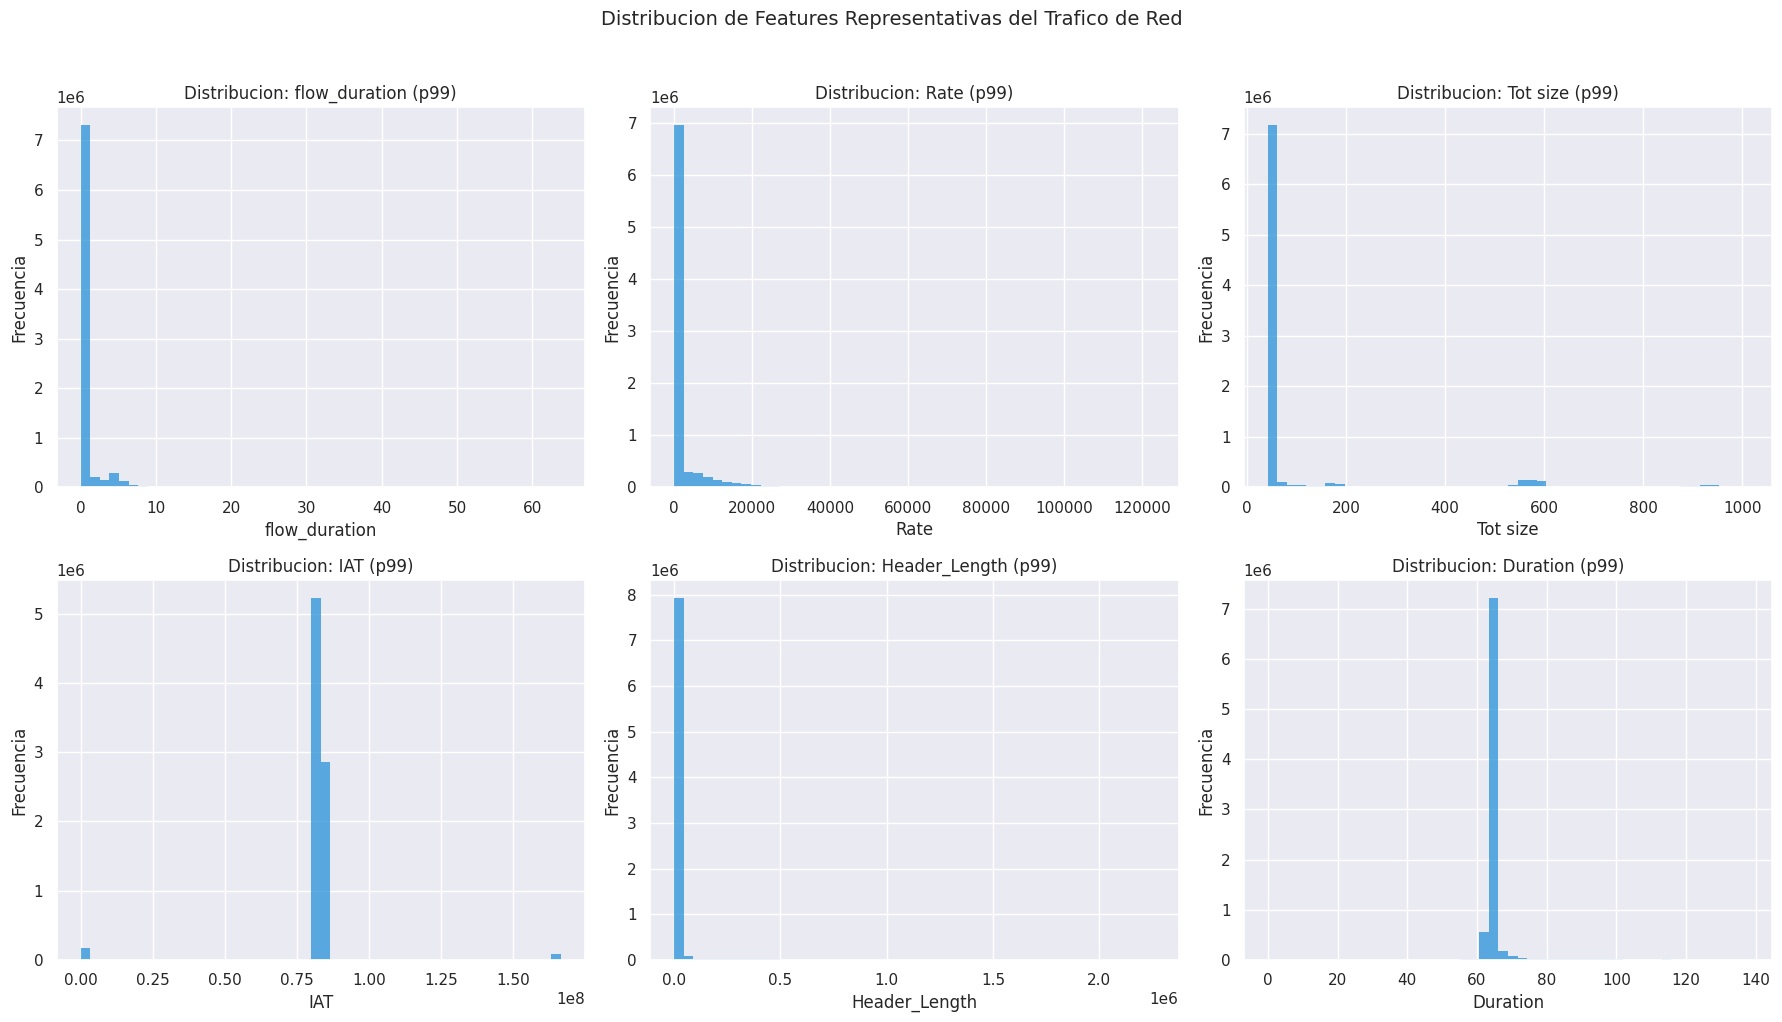

In [13]:
top_features = ['flow_duration', 'Rate', 'Tot size', 'IAT', 'Header_Length', 'Duration']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    p99 = df[col].quantile(0.99)
    data = df[col][df[col] <= p99].dropna()
    axes[i].hist(data, bins=50, color='#3498db', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'Distribucion: {col} (p99)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle("Distribucion de Features Representativas del Trafico de Red", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("distribucion_features.png", bbox_inches='tight')
plt.show()